In [74]:
#importing python classes and packages
import matplotlib.pyplot as plt
from tkinter.filedialog import askopenfilename
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
import seaborn as sns
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn import svm
from sklearn.linear_model import LogisticRegression
import shap
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
import catboost as cb

In [75]:
#load and display dataset values
dataset = pd.read_csv("Dataset/healthcare-dataset-stroke-data.csv")
dataset.fillna(0, inplace = True)
dataset

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,0.0,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,0.0,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


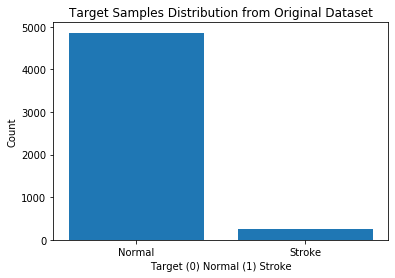

In [76]:
#finidng and plotting labels in dataset and in below graph we can see dataset is highly imbalance as one class contains
#so many instances and other contains very few instances and this imbalance we will handle using SMOTE
unique, count = np.unique(dataset['stroke'], return_counts = True)
labels = ['Normal', 'Stroke']
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Target (0) Normal (1) Stroke")
plt.ylabel("Count")
plt.title("Target Samples Distribution from Original Dataset")
plt.show()

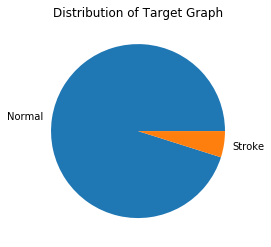

In [77]:
#graphs of different labels found in dataset
plt.pie(count, labels = labels)
plt.title("Distribution of Target Graph")
plt.show() 

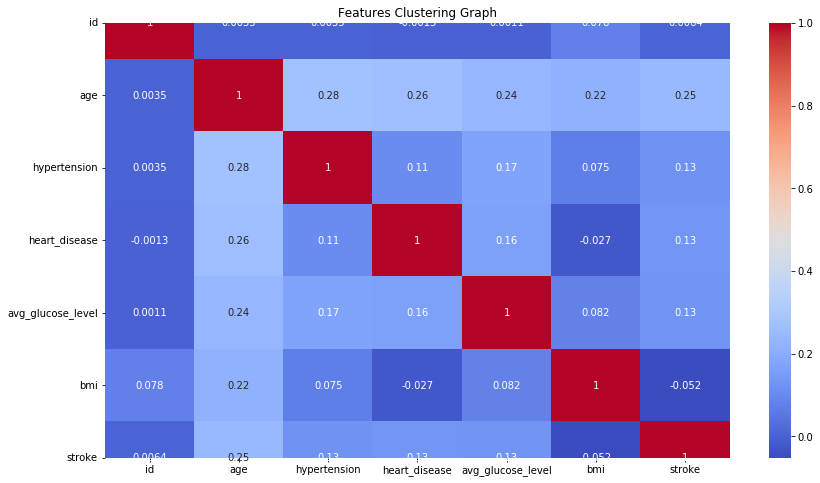

In [78]:
#find and plot features cluster correlation graph
plt.figure(figsize=(14,8))
sns.heatmap(dataset.corr(), cmap='coolwarm', annot=True)
plt.title("Features Clustering Graph")
plt.show()

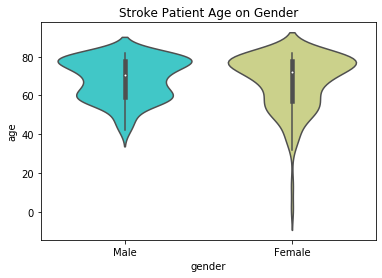

In [79]:
#plot graph of stroke patient based on age and gender
temp = dataset.loc[dataset['stroke'] == 1]
sns.violinplot(x='gender',y='age',data=temp,palette='rainbow')
plt.title("Stroke Patient Age on Gender")
plt.show()

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison


Text(0.5, 1.0, 'Age Distribution of Stroke Patients')

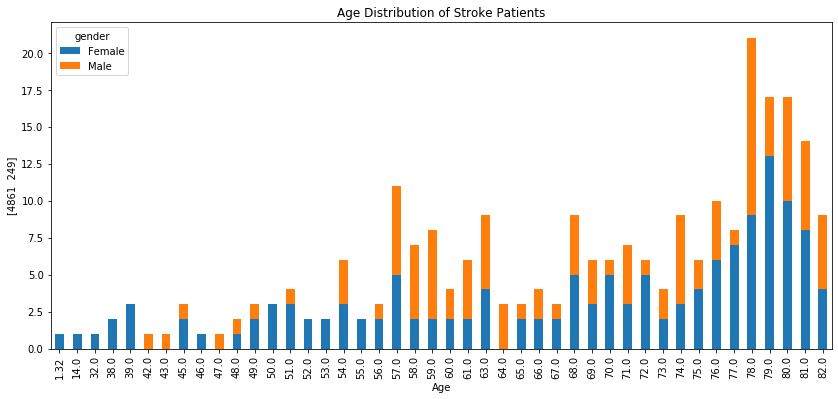

In [80]:
#plot graph of stroke patient based on age and gender in bar graph
data = temp[['age', 'gender']]
data.groupby(['age', 'gender']).size().unstack().plot(kind='bar', stacked=True, figsize=(14,6))
plt.xlabel("Age")
plt.ylabel(count)
plt.title("Age Distribution of Stroke Patients")

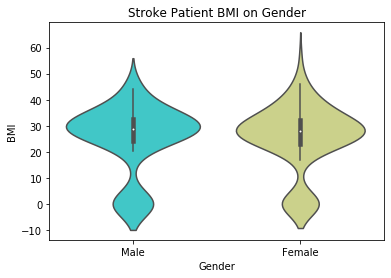

In [81]:
#graph of Stroke Patient using BMI on Gender
sns.violinplot(x='gender',y='bmi',data=temp,palette='rainbow')
plt.title("Stroke Patient BMI on Gender")
plt.xlabel("Gender")
plt.ylabel("BMI")
plt.show()

Text(0.5, 1.0, "Stroke Patient's Hypertension Status")

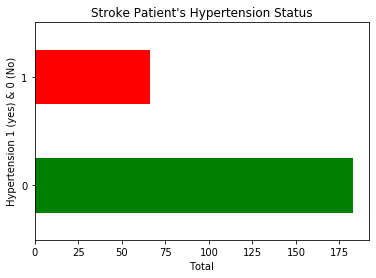

In [82]:
#finding and plotting graph in stroke patient suffering from hyper tension
data = temp[['hypertension']]
data.groupby(['hypertension']).size().plot(kind='barh', color=['g', 'r'])
plt.xlabel("Total")
plt.ylabel("Hypertension 1 (yes) & 0 (No)")
plt.title("Stroke Patient's Hypertension Status")

Text(0.5, 1.0, "Stroke Patient's Heart Disease")

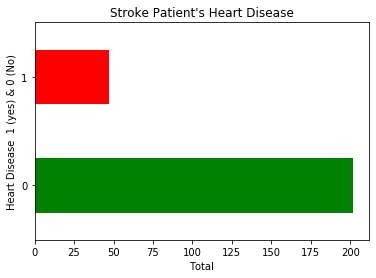

In [83]:
#finding and plotting graph in stroke patient suffering from heart disease
data = temp[['heart_disease']]
data.groupby(['heart_disease']).size().plot(kind='barh', color=['g', 'r'])
plt.xlabel("Total")
plt.ylabel("Heart Disease  1 (yes) & 0 (No)")
plt.title("Stroke Patient's Heart Disease")

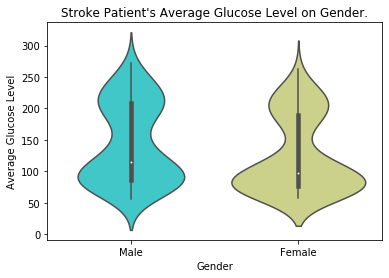

In [84]:
#finding and plotting graph in stroke patient with average glucose level
sns.violinplot(x='gender',y='avg_glucose_level',data=temp,palette='rainbow')
plt.title("Stroke Patient's Average Glucose Level on Gender.")
plt.xlabel("Gender")
plt.ylabel("Average Glucose Level")
plt.show()

Text(0.5, 1.0, "Stroke Patient's Smoking Status")

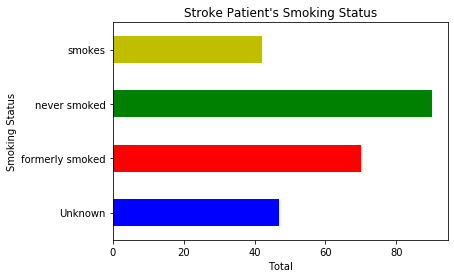

In [85]:
#finding and plotting graph in stroke patient doing smoking
data = temp[['smoking_status']]
data.groupby(['smoking_status']).size().plot(kind='barh', color=['b', 'r', 'g', 'y'])
plt.xlabel("Total")
plt.ylabel("Smoking Status")
plt.title("Stroke Patient's Smoking Status")

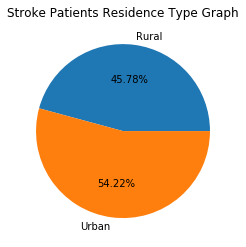

In [86]:
#finding and plotting graph of stroke patient using residence type
unique, count = np.unique(temp['Residence_type'], return_counts=True)
plt.pie(count, labels = unique, autopct='%1.2f%%')
plt.title("Stroke Patients Residence Type Graph")
plt.show() 

In [87]:
#convert categorical (non-numeric data) into numeric format using label encoder class
encoder1 = LabelEncoder()
encoder2 = LabelEncoder()
encoder3 = LabelEncoder()
encoder4 = LabelEncoder()
encoder5 = LabelEncoder()
dataset['gender'] = pd.Series(encoder1.fit_transform(dataset['gender'].astype(str)))#encode all str columns to numeric 
dataset['ever_married'] = pd.Series(encoder2.fit_transform(dataset['ever_married'].astype(str)))#encode all str columns to numeric
dataset['work_type'] = pd.Series(encoder3.fit_transform(dataset['work_type'].astype(str)))
dataset['Residence_type'] = pd.Series(encoder4.fit_transform(dataset['Residence_type'].astype(str)))
dataset['smoking_status'] = pd.Series(encoder5.fit_transform(dataset['smoking_status'].astype(str)))
dataset

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,51676,0,61.0,0,0,1,3,0,202.21,0.0,2,1
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,60182,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,1665,0,79.0,1,0,1,3,0,174.12,24.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,80.0,1,0,1,2,1,83.75,0.0,2,0
5106,44873,0,81.0,0,0,1,3,1,125.20,40.0,2,0
5107,19723,0,35.0,0,0,1,3,0,82.99,30.6,2,0
5108,37544,1,51.0,0,0,1,2,0,166.29,25.6,1,0


In [88]:
#drop ID column and then extract X training features and Y target label
Y = dataset['stroke'].ravel()
dataset.drop(['id', 'stroke'], axis = 1,inplace=True)
X = dataset.values
#normalized dataset features
sc1 = MinMaxScaler(feature_range = (0, 1))
X = sc1.fit_transform(X)#features normalization
print("Normalize Features : "+str(X))

Normalize Features : [[0.5        0.81689453 0.         ... 0.80126489 0.375      0.33333333]
 [0.         0.74365234 0.         ... 0.67902317 0.         0.66666667]
 [0.5        0.97558594 0.         ... 0.23451205 0.3329918  0.66666667]
 ...
 [0.         0.42626953 0.         ... 0.12865848 0.31352459 0.66666667]
 [0.5        0.62158203 0.         ... 0.51320284 0.26229508 0.33333333]
 [0.         0.53613281 0.         ... 0.13922999 0.26844262 0.        ]]


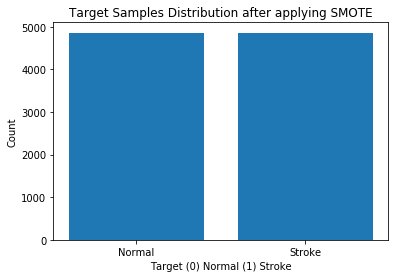

In [89]:
#now apply Smote to balance dataset
sm = SMOTE()
X, Y = sm.fit_resample(X, Y)
unique, count = np.unique(Y, return_counts=True)
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Target (0) Normal (1) Stroke")
plt.ylabel("Count")
plt.title("Target Samples Distribution after applying SMOTE")
plt.show()

In [90]:
#now select features uisng CHI Square features selection algorithm
print("Features available in dataset before selection : "+str(X.shape[1]))
features_selector = SelectKBest(score_func=chi2, k = 9)
selected_features = features_selector.fit_transform(X, Y)
print("Features available in dataset after selection : "+str(selected_features.shape[1]))

Features available in dataset before selection : 10
Features available in dataset after selection : 9


In [91]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(selected_features, Y, test_size=0.2) #split dataset into train and test
print()
print("Dataset train & test split as 80% dataset for training and 20% for testing")
print("Training Size (80%): "+str(X_train.shape[0])) #print training and test size
print("Testing Size (20%): "+str(X_test.shape[0]))
print()


Dataset train & test split as 80% dataset for training and 20% for testing
Training Size (80%): 7777
Testing Size (20%): 1945



In [92]:
#define global variables to calculate and store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []

In [93]:
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, predict, testY):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100     
    print()
    print(algorithm+' Accuracy  : '+str(a))
    print(algorithm+' Precision   : '+str(p))
    print(algorithm+' Recall      : '+str(r))
    print(algorithm+' FMeasure    : '+str(f))    
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    labels = unique
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()


Random Forest Accuracy  : 94.60154241645245
Random Forest Precision   : 94.62977776931265
Random Forest Recall      : 94.59721658292307
Random Forest FMeasure    : 94.60025779158543


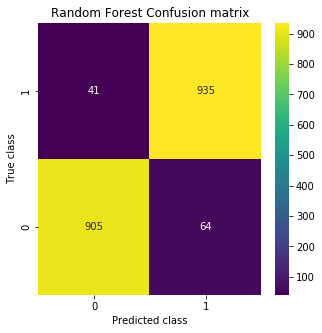

In [94]:
#train random forest algorithm on training dataset and test its prediction capability on test data
#now train Random Forest algorithm
rf_cls = RandomForestClassifier()
rf_cls.fit(X_train, y_train)
predict = rf_cls.predict(X_test)
calculateMetrics("Random Forest", predict, y_test)


Logistic Regression Accuracy  : 78.25192802056556
Logistic Regression Precision   : 78.32476139978792
Logistic Regression Recall      : 78.24257938723376
Logistic Regression FMeasure    : 78.23388464581897


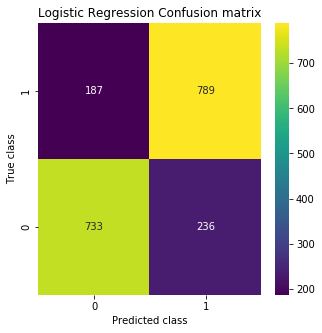

In [95]:
#now train LogisticRegression algorithm
lr_cls = LogisticRegression()#define regression object
lr_cls.fit(X_train, y_train)#train regression on training data
predict = lr_cls.predict(X_test)#perform prediction on test data
calculateMetrics("Logistic Regression", predict, y_test)#calculate accuracy and other metrics


SVM Accuracy  : 80.25706940874035
SVM Precision   : 80.62507094925282
SVM Recall      : 80.23719949584665
SVM FMeasure    : 80.19020459088189


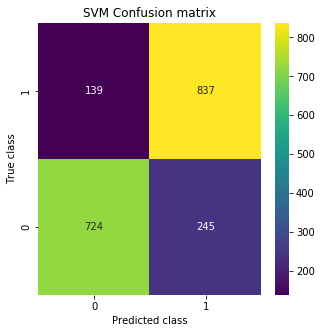

In [96]:
#now train SVM algorithm
svm_cls = svm.SVC()#define SVM object
svm_cls.fit(X_train, y_train)#train SVM on training data
predict = svm_cls.predict(X_test)#perform prediction on test data
calculateMetrics("SVM", predict, y_test)#calculate accuracy and other metrics


KNN Accuracy  : 92.13367609254499
KNN Precision   : 92.5878107457899
KNN Recall      : 92.11525529107243
KNN FMeasure    : 92.11024264612894


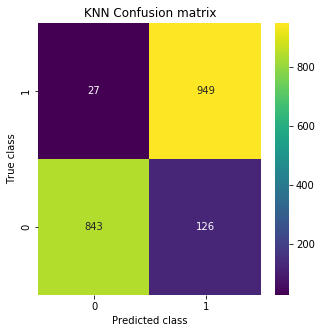

In [97]:
#now train KNN algorithm
knn_cls =  KNeighborsClassifier(n_neighbors=3)#define KNN object
knn_cls.fit(X_train, y_train)#train KNN on training data
predict = knn_cls.predict(X_test)#perform prediction on test data
calculateMetrics("KNN", predict, y_test)#calculate accuracy and other metrics


Naive Bayes Accuracy  : 77.68637532133677
Naive Bayes Precision   : 77.85783172030878
Naive Bayes Recall      : 77.67202329594478
Naive Bayes FMeasure    : 77.64566742299536


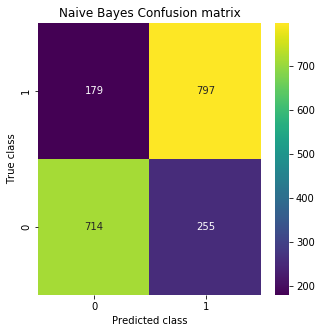

In [98]:
#now train Naive Bayes algorithm
nb_cls =  GaussianNB()#define Naive Bayes object
nb_cls.fit(X_train, y_train)#train Naive Bayes on training data
predict = nb_cls.predict(X_test)#perform prediction on test data
calculateMetrics("Naive Bayes", predict, y_test)#calculate accuracy and other metrics


XGBoost Accuracy  : 89.15167095115682
XGBoost Precision   : 89.40678778122724
XGBoost Recall      : 89.13728239354413
XGBoost FMeasure    : 89.1313991190076


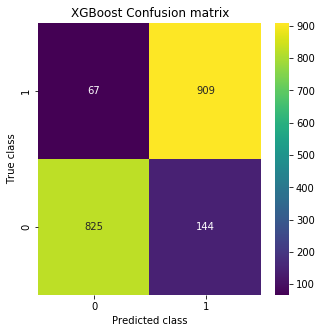

In [99]:
#now train XGBoost algorithm
xg_cls =  XGBClassifier(n_estimators=10)#define XGBOOST object
xg_cls.fit(X_train, y_train)#train XGBOost on training data
predict = xg_cls.predict(X_test)#perform prediction on test data
calculateMetrics("XGBoost", predict, y_test)#calculate accuracy and other metrics

0:	learn: 0.6258458	total: 20.4ms	remaining: 6.09s
1:	learn: 0.5783969	total: 31.6ms	remaining: 4.71s
2:	learn: 0.5263363	total: 41.1ms	remaining: 4.06s
3:	learn: 0.5049353	total: 50.7ms	remaining: 3.75s
4:	learn: 0.4765314	total: 59.6ms	remaining: 3.51s
5:	learn: 0.4610771	total: 68.4ms	remaining: 3.35s
6:	learn: 0.4393660	total: 77.5ms	remaining: 3.24s
7:	learn: 0.4277253	total: 87.5ms	remaining: 3.19s
8:	learn: 0.4142786	total: 96.4ms	remaining: 3.12s
9:	learn: 0.4005121	total: 105ms	remaining: 3.05s
10:	learn: 0.3916923	total: 114ms	remaining: 3s
11:	learn: 0.3713331	total: 123ms	remaining: 2.95s
12:	learn: 0.3662904	total: 132ms	remaining: 2.9s
13:	learn: 0.3572762	total: 140ms	remaining: 2.87s
14:	learn: 0.3493691	total: 149ms	remaining: 2.83s
15:	learn: 0.3443991	total: 157ms	remaining: 2.79s
16:	learn: 0.3359340	total: 166ms	remaining: 2.76s
17:	learn: 0.3314512	total: 175ms	remaining: 2.73s
18:	learn: 0.3214223	total: 186ms	remaining: 2.75s
19:	learn: 0.3144912	total: 197ms	re

162:	learn: 0.1321489	total: 1.59s	remaining: 1.34s
163:	learn: 0.1316530	total: 1.6s	remaining: 1.33s
164:	learn: 0.1312416	total: 1.61s	remaining: 1.32s
165:	learn: 0.1309034	total: 1.62s	remaining: 1.31s
166:	learn: 0.1297524	total: 1.63s	remaining: 1.3s
167:	learn: 0.1291528	total: 1.64s	remaining: 1.29s
168:	learn: 0.1287740	total: 1.65s	remaining: 1.28s
169:	learn: 0.1283510	total: 1.66s	remaining: 1.27s
170:	learn: 0.1281317	total: 1.67s	remaining: 1.26s
171:	learn: 0.1275649	total: 1.68s	remaining: 1.25s
172:	learn: 0.1269497	total: 1.69s	remaining: 1.24s
173:	learn: 0.1265558	total: 1.7s	remaining: 1.23s
174:	learn: 0.1262746	total: 1.71s	remaining: 1.22s
175:	learn: 0.1259012	total: 1.72s	remaining: 1.21s
176:	learn: 0.1254236	total: 1.73s	remaining: 1.2s
177:	learn: 0.1249293	total: 1.74s	remaining: 1.19s
178:	learn: 0.1246756	total: 1.75s	remaining: 1.18s
179:	learn: 0.1242360	total: 1.75s	remaining: 1.17s
180:	learn: 0.1232217	total: 1.77s	remaining: 1.16s
181:	learn: 0.12

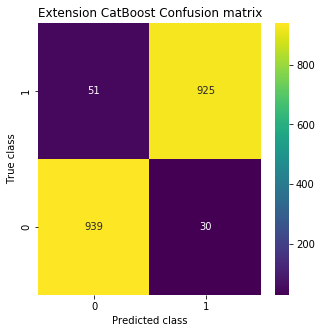

In [100]:
#now traon extension CATBOOST algorithm as extension which is more advanced then other ML algorithm
cb_cls = cb.CatBoostClassifier(iterations=300, learning_rate=0.1)
cb_cls.fit(X_train, y_train)#train CatBoost on training data
predict = cb_cls.predict(X_test)#perform prediction on test data
calculateMetrics("Extension CatBoost", predict, y_test)#calculate accuracy and other metrics

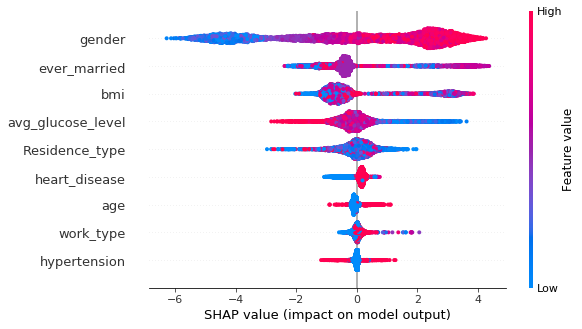

In [101]:
#using shapely we can explain model which can show what features help in gaining more accuracy
columns = ['gender','age','hypertension','heart_disease','ever_married','work_type','Residence_type','avg_glucose_level','bmi']
explainer = shap.TreeExplainer(cb_cls)
shap_values = explainer.shap_values(X_train) #explainer will set on training data
shap.summary_plot(shap_values, X_train, feature_names=columns)#now explain features importance using plot

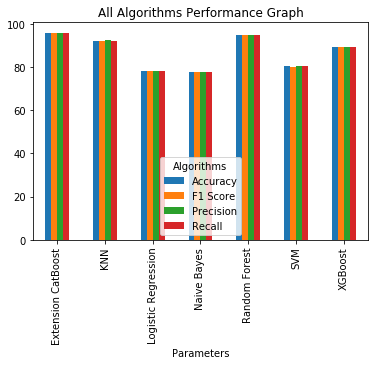

In [102]:
#plot comparison between all algortihms
df = pd.DataFrame([['Random Forest','Precision',precision[0]],['Random Forest','Recall',recall[0]],['Random Forest','F1 Score',fscore[0]],['Random Forest','Accuracy',accuracy[0]],
                   ['Logistic Regression','Precision',precision[1]],['Logistic Regression','Recall',recall[1]],['Logistic Regression','F1 Score',fscore[1]],['Logistic Regression','Accuracy',accuracy[1]],
                   ['SVM','Precision',precision[2]],['SVM','Recall',recall[2]],['SVM','F1 Score',fscore[2]],['SVM','Accuracy',accuracy[2]],
                   ['KNN','Precision',precision[3]],['KNN','Recall',recall[3]],['KNN','F1 Score',fscore[3]],['KNN','Accuracy',accuracy[3]],
                   ['Naive Bayes','Precision',precision[4]],['Naive Bayes','Recall',recall[4]],['Naive Bayes','F1 Score',fscore[4]],['Naive Bayes','Accuracy',accuracy[4]],
                   ['XGBoost','Precision',precision[5]],['XGBoost','Recall',recall[5]],['XGBoost','F1 Score',fscore[5]],['XGBoost','Accuracy',accuracy[5]],
                   ['Extension CatBoost','Precision',precision[6]],['Extension CatBoost','Recall',recall[6]],['Extension CatBoost','F1 Score',fscore[6]],['Extension CatBoost','Accuracy',accuracy[6]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar')
plt.title("All Algorithms Performance Graph")
plt.show()

In [103]:
#showing all algorithms with scenario A and B performance values
columns = ["Algorithm Name","Precison","Recall","FScore","Accuracy"]
values = []
algorithm_names = ["Random Forest","Logistic Regression", "SVM", "KNN", "Naive Bayes", "XGBOost", "Extension CatBoost"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i],precision[i],recall[i],fscore[i],accuracy[i]])
    
temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,Precison,Recall,FScore,Accuracy
0,Random Forest,94.629778,94.597217,94.600258,94.601542
1,Logistic Regression,78.324761,78.242579,78.233885,78.251928
2,SVM,80.625071,80.237199,80.190205,80.257069
3,KNN,92.587811,92.115255,92.110243,92.133676
4,Naive Bayes,77.857832,77.672023,77.645667,77.686375
5,XGBOost,89.406788,89.137282,89.131399,89.151671
6,Extension CatBoost,95.853562,95.839307,95.835260,95.835476


In [104]:
testData = pd.read_csv("Dataset/testData.csv")#reading test data
testData.fillna(0, inplace = True)
temp = testData.values
testData['gender'] = pd.Series(encoder1.transform(testData['gender'].astype(str)))#converting non-numeric data to numeric
testData['ever_married'] = pd.Series(encoder2.transform(testData['ever_married'].astype(str)))
testData['work_type'] = pd.Series(encoder3.transform(testData['work_type'].astype(str)))
testData['Residence_type'] = pd.Series(encoder4.transform(testData['Residence_type'].astype(str)))
testData['smoking_status'] = pd.Series(encoder5.transform(testData['smoking_status'].astype(str)))
testData.drop(['id'], axis=1, inplace=True)#drop id column
testData = testData.values
test = sc1.transform(testData)#normalizing values
test = features_selector.transform(test)#select relevant features using CHI2 selector
predict = cb_cls.predict(test)#performing prediction on test data using XGBOOST
for i in range(len(predict)):
    print("Test Data = "+str(temp[i])+" Predicted As ====> "+labels[predict[i]]+"\n")

Test Data = [17739 'Male' 57 0 0 'Yes' 'Private' 'Rural' 84.96 36.7 'Unknown'] Predicted As ====> Normal

Test Data = [12095 'Female' 61 0 1 'Yes' 'Govt_job' 'Rural' 120.46 36.8 'smokes'] Predicted As ====> Stroke

Test Data = [12175 'Female' 54 0 0 'Yes' 'Private' 'Urban' 104.51 27.3 'smokes'] Predicted As ====> Stroke

Test Data = [8213 'Male' 78 0 1 'Yes' 'Private' 'Urban' 219.84 0.0 'Unknown'] Predicted As ====> Stroke

Test Data = [27419 'Female' 59 0 0 'Yes' 'Private' 'Rural' 76.15 0.0 'Unknown'] Predicted As ====> Stroke

Test Data = [60491 'Female' 78 0 0 'Yes' 'Private' 'Urban' 58.57 24.2 'Unknown'] Predicted As ====> Normal

Test Data = [12109 'Female' 81 1 0 'Yes' 'Private' 'Rural' 80.43 29.7 'never smoked'] Predicted As ====> Stroke

Test Data = [5317 'Female' 79 0 1 'Yes' 'Private' 'Urban' 214.09 28.2 'never smoked'] Predicted As ====> Stroke

Test Data = [58202 'Female' 50 1 0 'Yes' 'Self-employed' 'Rural' 167.41 30.9
 'never smoked'] Predicted As ====> Normal

